# Today we are going to study WEB-SCRAPING

------
------

sometime, many website hvaing data that we need don't wanted to have access to their data.So, they don't provide us the APIs.

In these cases, we usually do web-scraping to collect some important data. It is legal for only professional work.

here, we go page by page to extract data.We do to each page to extract data.

the things we are going to derive : 

1} Name

2}Rating

3}No. of reviews

4}type like public or private or governmental or something else

5}HQ

6}How old the company is?

7}No. of employees

8}Tags

9} About

-----
-----

In [1]:
import pandas as pd
import requests
from bs4 import BeautifulSoup   #this is the main web scraping library we will be using

initially we have to generate a http request using a request library

In [2]:
requests.get('https://www.ambitionbox.com/list-of-companies?campaign=desktop_nav&page=1')

<Response [403]>

there is a problem overhere. Response 403 => means => server have rejected my request to give me the access to it's data.
this is what we are going to learn to deal with.

In [3]:
#we can use .text to get the text content of the response
requests.get('https://www.ambitionbox.com/list-of-companies?campaign=desktop_nav&page=1').text
#you can see ACCESS DENIED

'<HTML><HEAD>\n<TITLE>Access Denied</TITLE>\n</HEAD><BODY>\n<H1>Access Denied</H1>\n \nYou don\'t have permission to access "http&#58;&#47;&#47;www&#46;ambitionbox&#46;com&#47;list&#45;of&#45;companies&#63;" on this server.<P>\nReference&#32;&#35;18&#46;4c3cd717&#46;1779812421&#46;f390a880\n<P>https&#58;&#47;&#47;errors&#46;edgesuite&#46;net&#47;18&#46;4c3cd717&#46;1779812421&#46;f390a880</P>\n</BODY>\n</HTML>\n'

in development there is a thing known as robots.text . Which ever file name we will write in that , no google or web crawler can access it like we have tried to do like above

what we do is we disguish ourselves like a browser request instead of http request to get some access to the data, so that the website thoughts that the request is coming from a human.
we just have to copy and paste the header before sending request.

###IMP

In [4]:
headers={'User-Agent':'Mozilla/5.0 (Windows NT 6.3; Win 64 ; x64) Apple WeKit /537.36(KHTML , like Gecko) Chrome/80.0.3987.162 Safari/537.36'}
#just learn and remember the above line, we will be using it in all our web scraping projects. It is used to bypass the access denied error.

In [5]:

requests.get('https://www.ambitionbox.com/list-of-companies?campaign=desktop_nav&page=1',headers=headers)

#also we have to pass the headers parameter in the get request to bypass the access denied error

<Response [200]>

if we do .text in the above code then we will get the webpage HTML code

In [6]:
web_page = requests.get('https://www.ambitionbox.com/list-of-companies?campaign=desktop_nav&page=1',headers=headers).text

now the main goal is to pass this and fetch the necessary info. There we will get the use of this beautifulsoup

In [7]:
#now we will pass the web page that we got to beautifulsoup to parse it and extract the data we want
soup = BeautifulSoup(web_page,'lxml')   #lxml = html parser
#this lxml helps us to parse the html content of the web page and extract the data we want. 


now, we have a object of beautiful class . now, using this object we can use the beautifulsoup functions

<!DOCTYPE html>
<html data-n-head="%7B%22lang%22:%7B%22ssr%22:%22en%22%7D%7D" data-n-head-ssr="" lang="en">
 <head>
  <meta charset="utf-8"/>
  <meta content="width=device-width,initial-scale=1,minimum-scale=1" name="viewport"/>
  <meta content="IE=edge" http-equiv="X-UA-Compatible"/>
  <link href="/assets/next/manifest.json" rel="manifest"/>
  <style>
   @media only screen and (min-width:767px){.trp-img{width:400px!important;max-width:400px!important}}
  </style>
  <script defer="" src="/static/js/env-runtime.js">
  </script>
  <script>
   window.dataLayer=window.dataLayer||[],window.gtag=window.gtag||function(){window.dataLayer.push(arguments)},gtag("js",new Date),window.initialDate=(new Date).toISOString()
  </script>
  <script>
   window.Prism=window.Prism||{},window.Prism.manual=!0
  </script>
  <title>
   Top Companies in India | AmbitionBox
  </title>
  <meta content="2026 AmbitionBox" data-n-head="ssr" name="copyright"/>
  <meta content="1 day" data-n-head="ssr" name="revisit-a
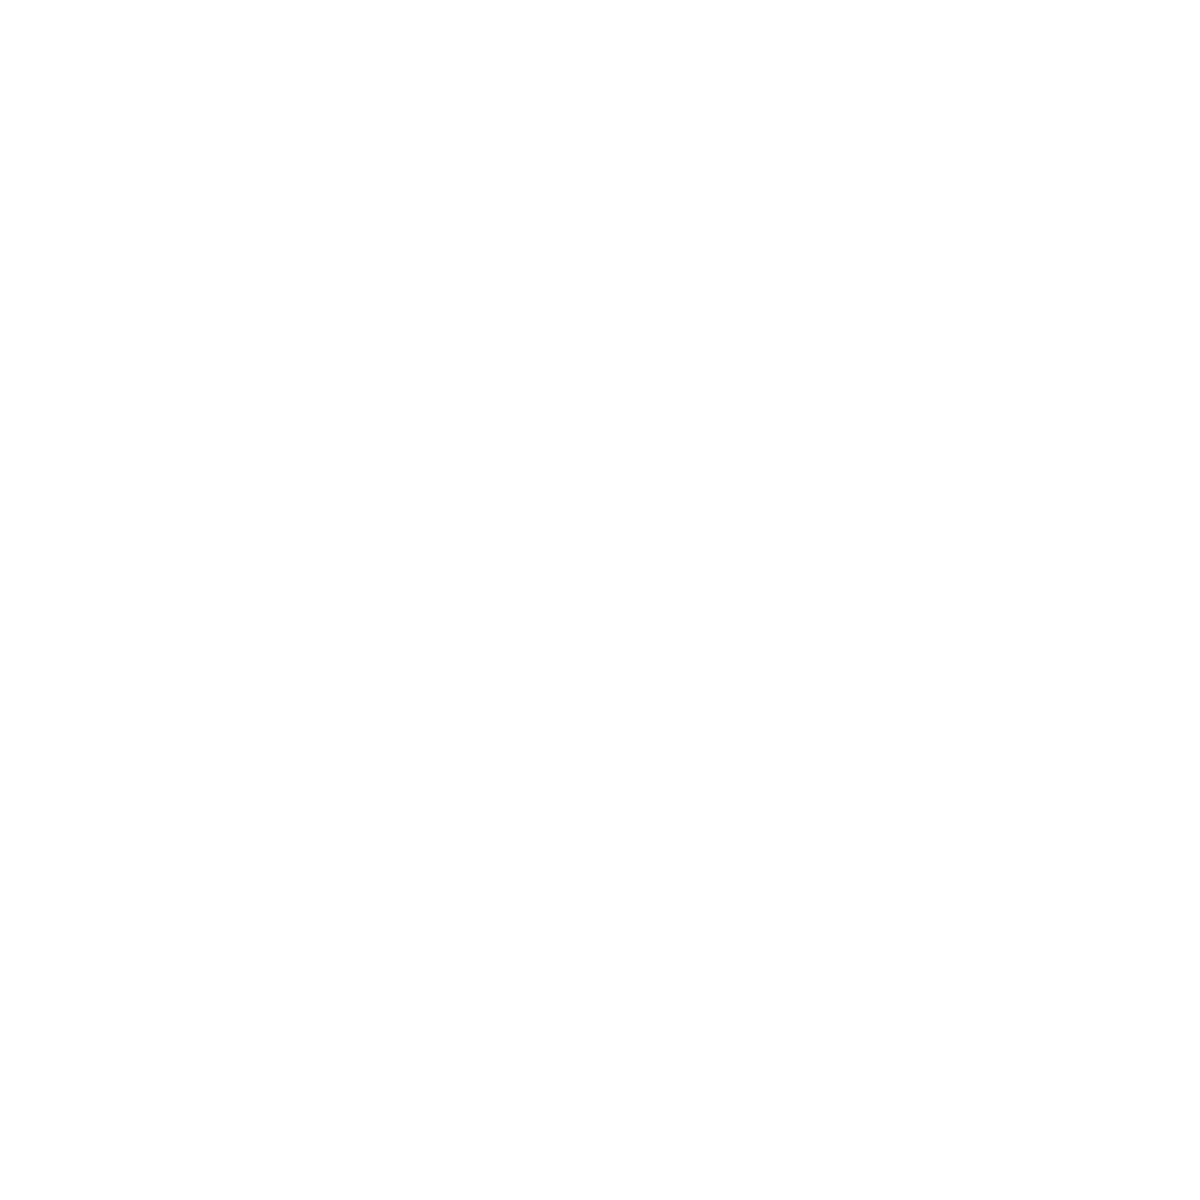

In [8]:
#there is a function called prettify() in beautifulsoup which helps us to see the html content in a more readable format but you have to print it out
print(soup.prettify())

In [9]:
soup.find_all('h1')  #this will find all the h1 tags in the web page and return a list of them
#this will print all h1 tags present in the web page

[<h1 class="companyListing__collectionTopHeadingCont" data-v-bb58b91c=""><div class="companyListing__collectionTopHeading" data-v-bb58b91c="">
 					Top Companies in
 				</div> <div class="companyListing__collectionIndiaHeading" data-v-bb58b91c=""><img data-v-bb58b91c="" height="12" src="https://static.ambitionbox.com/static/loc/loc-star.png" width="12"/>
 					INDIA
 					<img data-v-bb58b91c="" height="12" src="https://static.ambitionbox.com/static/loc/loc-star.png" width="12"/></div></h1>]

In [10]:
soup.find_all('h1')[0]  #this will print the first h1 tag present in the web page

<h1 class="companyListing__collectionTopHeadingCont" data-v-bb58b91c=""><div class="companyListing__collectionTopHeading" data-v-bb58b91c="">
					Top Companies in
				</div> <div class="companyListing__collectionIndiaHeading" data-v-bb58b91c=""><img data-v-bb58b91c="" height="12" src="https://static.ambitionbox.com/static/loc/loc-star.png" width="12"/>
					INDIA
					<img data-v-bb58b91c="" height="12" src="https://static.ambitionbox.com/static/loc/loc-star.png" width="12"/></div></h1>

In [11]:
#if we want text from this h1 tag element then we just have to add .text attribute at the end of it
soup.find_all('h1')[0].text

'\n\t\t\t\t\tTop Companies in\n\t\t\t\t \n\t\t\t\t\tINDIA\n\t\t\t\t\t'

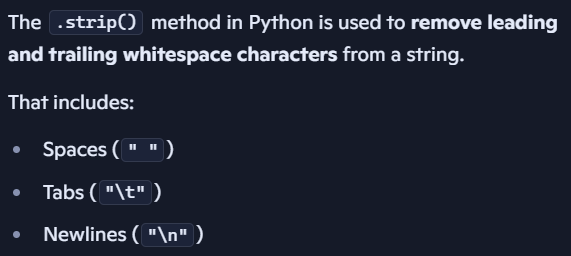

to remove the above extra typing we use the .strip function for this.

In [12]:
soup.find_all('h1')[0].text.strip()

'Top Companies in\n\t\t\t\t \n\t\t\t\t\tINDIA'

to remove the internal part that we don't required we use : 

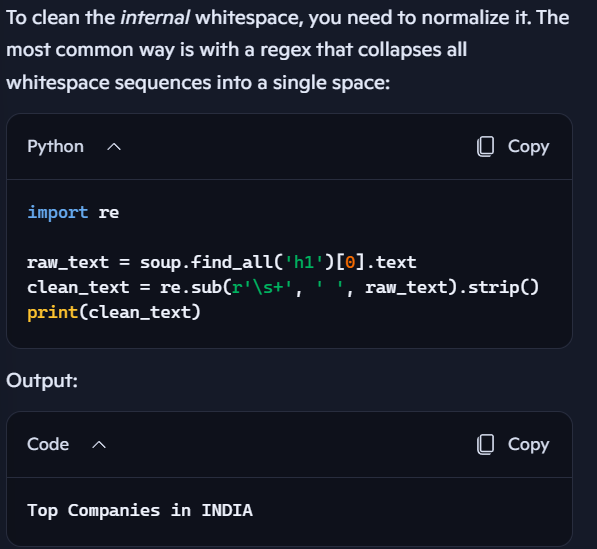

In [13]:
raw_text = soup.find_all('h1')[0].text

In [14]:
import re

In [15]:
clean_text = re.sub(r'\s+', ' ', raw_text).strip()

In [16]:
clean_text

'Top Companies in INDIA'

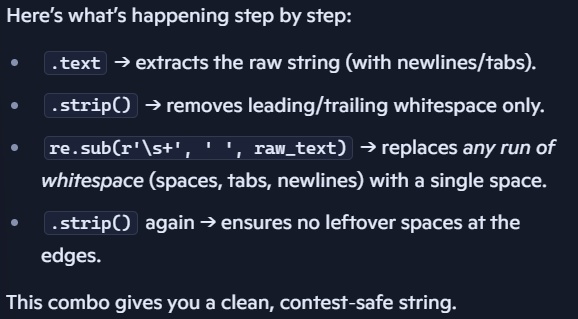

# IMPORTANT  ↑

In [17]:
soup.find_all('h2')

[<h2 class="companyListing__title">
 								Companies in India
 							</h2>,
 <h2 class="companyCardWrapper__companyName" title="TCS">
 									TCS
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="Accenture">
 									Accenture
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="Wipro">
 									Wipro
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="Cognizant">
 									Cognizant
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="Capgemini">
 									Capgemini
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="HDFC Bank">
 									HDFC Bank
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="Infosys">
 									Infosys
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="HCLTech">
 									HCLTech
 								</h2>,
 <h2 class="companyCardWrapper__companyName" title="ICICI Bank">
 									ICICI Bank
 								</h2>,
 <h2 class="companyCardWrapper__companyName" ti

this list have mulptiple h2 seperated by commas.
we can use len function with the help of which we can find the number of h2 in the page

In [18]:
len (soup.find_all('h2'))

24

In [19]:
for i in soup.find_all('h2'):
    print(i.text)


								Companies in India
							

									TCS
								

									Accenture
								

									Wipro
								

									Cognizant
								

									Capgemini
								

									HDFC Bank
								

									Infosys
								

									HCLTech
								

									ICICI Bank
								

									Tech Mahindra
								

									Genpact
								

									TP 
								

									Jio
								

									Axis Bank
								

									Concentrix Corporation
								

									Amazon
								

									Reliance Retail
								

									iEnergizer
								

									LTIMindtree
								

									IBM
								

				Popular Collections by Industries
			

				Popular Collections by Cities
			

				Popular Collections by Roles
			


In [20]:
#there is a tap or slash in the end of the text of h2 tags, we can remove it by using strip() function
for i in soup.find_all('h2'):
    print(i.text.strip())

Companies in India
TCS
Accenture
Wipro
Cognizant
Capgemini
HDFC Bank
Infosys
HCLTech
ICICI Bank
Tech Mahindra
Genpact
TP
Jio
Axis Bank
Concentrix Corporation
Amazon
Reliance Retail
iEnergizer
LTIMindtree
IBM
Popular Collections by Industries
Popular Collections by Cities
Popular Collections by Roles


now to use the unwanted lines I am going to use a  new way acc to copilot

In [21]:
#here we have formed a list of unwanted h2 tags, we will remove them from the output
unwanted = [
    "Companies in India",
    "Popular Collections by Industries",
    "Popular Collections by Cities",
    "Popular Collections by Roles"
]
for i in soup.find_all('h2'):
    if i.text.strip() not in unwanted:
        print(i.text.strip())

TCS
Accenture
Wipro
Cognizant
Capgemini
HDFC Bank
Infosys
HCLTech
ICICI Bank
Tech Mahindra
Genpact
TP
Jio
Axis Bank
Concentrix Corporation
Amazon
Reliance Retail
iEnergizer
LTIMindtree
IBM


In [22]:
soup.find_all('div', class_='rating_star_container')

[<div class="rating_star_container" style="line-height:20px;"><svg fill="none" height="20" viewbox="0 0 20 20" width="20" xmlns="http://www.w3.org/2000/svg"><rect fill="#FFBA01" height="20" rx="4" width="20"></rect> <path d="M6.295 16L7.27 11.5632L4 8.57895L8.32 8.18421L10 4L11.68 8.18421L16 8.57895L12.73 11.5632L13.705 16L10 13.6474L6.295 16Z" fill="white"></path></svg> <div class="rating_text rating_text--md"><div style="height:auto;">
 			3.3<!-- --></div></div></div>,
 <div class="rating_star_container" style="line-height:20px;"><svg fill="none" height="20" viewbox="0 0 20 20" width="20" xmlns="http://www.w3.org/2000/svg"><rect fill="#9acd32" height="20" rx="4" width="20"></rect> <path d="M6.295 16L7.27 11.5632L4 8.57895L8.32 8.18421L10 4L11.68 8.18421L16 8.57895L12.73 11.5632L13.705 16L10 13.6474L6.295 16Z" fill="white"></path></svg> <div class="rating_text rating_text--md"><div style="height:auto;">
 			3.7<!-- --></div></div></div>,
 <div class="rating_star_container" style="lin

In [23]:
len(soup.find_all('div', class_='rating_star_container'))
#this will helps us to check whether we are getting the correct number of div tags with class name 'rating_star_container' or not, 
# as we know there are 30 companies in the web page so we should get 30 div tags with class name 'rating_star_container'

20

In [24]:
for i in soup.find_all('div', class_='rating_star_container'):      #learn this as in new HTML code this type of things are used
    print(i.text.strip())

#we use the atttribute 'class_' to find the div tags with class name 'rating_star_container' and - 
# - then we print the text of those div tags after stripping the extra spaces from it.

3.3
3.7
3.6
3.7
3.6
3.8
3.5
3.4
4.0
3.4
3.6
3.9
4.4
3.6
3.6
3.9
3.9
4.6
3.6
3.9


In [25]:
for i in soup.find_all('a',class_ = 'companyCardWrapper__ActionWrapper'):
    print(i.text.strip())

1.1L Reviews
10.2L Salaries
11.9k Interviews
4.1k Jobs
10.8k Benefits
93 Photos
73.8k Reviews
7L Salaries
9.4k Interviews
34.9k Jobs
6.8k Benefits
49 Photos
65.4k Reviews
4.9L Salaries
6.9k Interviews
302 Jobs
4.7k Benefits
114 Photos
61.7k Reviews
6.1L Salaries
6.5k Interviews
547 Jobs
5.5k Benefits
96 Photos
53.7k Reviews
4.9L Salaries
5.6k Interviews
2.1k Jobs
3.7k Benefits
42 Photos
52.7k Reviews
1.5L Salaries
3.1k Interviews
334 Jobs
3.3k Benefits
89 Photos
49k Reviews
5.3L Salaries
8.5k Interviews
2k Jobs
4.8k Benefits
120 Photos
46.2k Reviews
3.9L Salaries
4.6k Interviews
232 Jobs
3.8k Benefits
71 Photos
46.1k Reviews
1.5L Salaries
3k Interviews
13 Jobs
3.7k Benefits
73 Photos
43.5k Reviews
2.9L Salaries
4.6k Interviews
592 Jobs
3.4k Benefits
79 Photos
42.6k Reviews
2.4L Salaries
3.9k Interviews
623 Jobs
3.6k Benefits
66 Photos
38.9k Reviews
99.9k Salaries
2.3k Interviews
1.4k Jobs
1.9k Benefits
38 Photos
33.7k Reviews
61.9k Salaries
4.4k Interviews
-- Jobs
2.6k Benefits
93 Phot

In [26]:
#this is for all the numbers in that page if you can see only.
for i in soup.find_all('span',class_ = 'companyCardWrapper__ActionCount'):
    print(i.text.strip())

1.1L
10.2L
11.9k
4.1k
10.8k
93
73.8k
7L
9.4k
34.9k
6.8k
49
65.4k
4.9L
6.9k
302
4.7k
114
61.7k
6.1L
6.5k
547
5.5k
96
53.7k
4.9L
5.6k
2.1k
3.7k
42
52.7k
1.5L
3.1k
334
3.3k
89
49k
5.3L
8.5k
2k
4.8k
120
46.2k
3.9L
4.6k
232
3.8k
71
46.1k
1.5L
3k
13
3.7k
73
43.5k
2.9L
4.6k
592
3.4k
79
42.6k
2.4L
3.9k
623
3.6k
66
38.9k
99.9k
2.3k
1.4k
1.9k
38
33.7k
61.9k
4.4k
--
2.6k
93
33.4k
1L
2k
239
2.2k
121
32.4k
1.3L
2k
20
3.1k
67
31.6k
1.6L
6k
55
3.6k
95
27.5k
75.7k
2k
86
1.9k
142
27.2k
24.8k
1.6k
104
552
29
26.6k
2L
3.5k
508
802
34
25.9k
2.2L
2.6k
1.8k
2.6k
23


In [27]:
#this will bring all reviews no. only -> ✕
for i in soup.find_all('span', class_='companyCardWrapper__ActionCount'):
    text = i.text.strip()
    if "Reviews" in text:
        print(text)


In [28]:
#for reviews we will use this code
for block in soup.find_all('div', class_='companyCardWrapper__tertiaryInformation'):
    count = block.find('span', class_='companyCardWrapper__ActionCount')
    title = block.find('span', class_='companyCardWrapper__ActionTitle')
    if title and "Reviews" in title.text:
        print(count.text.strip())
        #this will check for both review and the count of reviews and print only the count of reviews.


1.1L
73.8k
65.4k
61.7k
53.7k
52.7k
49k
46.2k
46.1k
43.5k
42.6k
38.9k
33.7k
33.4k
32.4k
31.6k
27.5k
27.2k
26.6k
25.9k


In [29]:
#now we wanted to get HQ location
for i in soup.find_all('span',class_ = 'companyCardWrapper__interLinking'):
    print(i.text.strip())

IT Services & Consulting | Bengaluru +444 other locations
IT Services & Consulting | Bengaluru +259 other locations
IT Services & Consulting | Hyderabad +374 other locations
IT Services & Consulting | Hyderabad +232 other locations
IT Services & Consulting | Bengaluru +182 other locations
Banking | Mumbai +1853 other locations
IT Services & Consulting | Bengaluru +246 other locations
IT Services & Consulting | Chennai +231 other locations
Banking | Mumbai +1445 other locations
IT Services & Consulting | Hyderabad +321 other locations
Analytics & KPO | Hyderabad +181 other locations
BPO | Mumbai +256 other locations
Telecom | Mumbai +1959 other locations
Banking | Mumbai +1523 other locations
BPO | Bengaluru +183 other locations
Internet | Bengaluru +516 other locations
Retail | Mumbai +1161 other locations
BPO | Noida +53 other locations
IT Services & Consulting | Bengaluru +145 other locations
IT Services & Consulting | Bengaluru +162 other locations


till here, we have done it little wrong . We have to first take the container

-----
-----

we will be doing a fresh start from this point as till now we have learnt the ways to extract data using web scrapping

-----
-----

In [30]:
#first we will just take all the info in the company container in the form of a company container
company = soup.find_all('div',class_ = 'companyCardWrapper')

In [31]:
len(company)        #this will give us the number of company containers present in the web page, as we know there are 20 companies in the web page so we should get 20 company containers.

20

In [32]:
#now we will extract the details about each companies from the company container into a empty list
name = []
for i in company:
    name.append(i.find('h2').text.strip())
    #here, 1st we have seen that we are dealing with only containers of details, so we will dont face any extra h2.
    #also ,then we have done find('h2') to find the h2 tag in the company container and 
    # then we have used .text to get the text of that h2 tag and 
    # then we have used strip() to remove the extra spaces from it and 
    # then we have appended it to the name list using append() function.


In [33]:
name

['TCS',
 'Accenture',
 'Wipro',
 'Cognizant',
 'Capgemini',
 'HDFC Bank',
 'Infosys',
 'HCLTech',
 'ICICI Bank',
 'Tech Mahindra',
 'Genpact',
 'TP',
 'Jio',
 'Axis Bank',
 'Concentrix Corporation',
 'Amazon',
 'Reliance Retail',
 'iEnergizer',
 'LTIMindtree',
 'IBM']

In [34]:
#similar to that:
#here find will work because there is one review cotainer in each company container.
rating = []
reviews = []
for i in company:
    rating.append(i.find('div', class_='rating_star_container').text.strip())
    reviews_text = i.find('span', class_ = 'companyCardWrapper__companyRatingCount').text.strip()

    #learn the below method to give the clarity of the unnecessary brackets
    clean_review_text = reviews_text.strip("()") #this will remove the parentheses from the reviews text
    reviews.append(clean_review_text + " reviews")  #this will append the clean review text with " reviews" to the reviews list. We are adding " reviews" to make it more readable and understandable.

In [35]:
print(rating)
print("\n")
print(reviews)

['3.3', '3.7', '3.6', '3.7', '3.6', '3.8', '3.5', '3.4', '4.0', '3.4', '3.6', '3.9', '4.4', '3.6', '3.6', '3.9', '3.9', '4.6', '3.6', '3.9']


['1.1L reviews', '73.8k reviews', '65.4k reviews', '61.7k reviews', '53.7k reviews', '52.7k reviews', '49k reviews', '46.2k reviews', '46.1k reviews', '43.5k reviews', '42.6k reviews', '38.9k reviews', '33.7k reviews', '33.4k reviews', '32.4k reviews', '31.6k reviews', '27.5k reviews', '27.2k reviews', '26.6k reviews', '25.9k reviews']


In [36]:
company

[<div class="companyCardWrapper" itemprop="itemListElement" itemscope="itemscope" itemtype="http://schema.org/ListItem"><meta content="1" itemprop="position"/> <meta content="TCS" itemprop="name"/> <meta content="Tata Consultancy Services" itemprop="alternateName"/> <meta content="https://www.ambitionbox.com/overview/tcs-overview" itemprop="url"/> <meta content="https://static.ambitionbox.com/alpha/company/photos/logos/tcs.jpg" itemprop="image"/> <div class="companyCardWrapper__primaryInformation"><div class="companyCardWrapper__companyLogo"><img alt="Tata Consultancy Services logo" height="50" loading="lazy" onerror="this.onerror=null;this.src='/static/icons/company-placeholder.svg';" src="https://static.ambitionbox.com/assets/v2/images/rs:fit:200:200:false:false/aHR0cHM6Ly9tZWRpYS5uYXVrcmkuY29tL21lZGlhL2FiY29tcGxvZ28vdGNzLW9yaWdpbmFsLmpwZw.webp" width="50"/></div> <div class="companyCardWrapper__metaInformation"><div class="companyCardWrapper__header"><div class="companyCardWrapper__

now, company is a big container which contains many div, 1st div will be with index 0, then in that if we just do with index 0 and in the same do find_all('',class_ = '') then wo bs ek pehle wale ka dega.phir, we know that it output will be a list theen the index 0 will be the 1st term , and so on.

In [37]:
company[0].find_all('a',class_ = 'companyCardWrapper__ActionWrapper')[0].text.strip()

'1.1L Reviews'

In [38]:
name = []
rating = []
reviews = []
salary =[]
interviews = []
jobs = []
benefits = []
HQ = []

for i in company:
    name.append(i.find('h2').text.strip())
    rating.append(i.find('div', class_='rating_star_container').text.strip())
    reviews.append(i.find_all('a',class_ = 'companyCardWrapper__ActionWrapper')[0].text.strip())
    salary.append(i.find_all('a',class_ = 'companyCardWrapper__ActionWrapper')[1].text.strip())
    interviews.append(i.find_all('a',class_ = 'companyCardWrapper__ActionWrapper')[2].text.strip())
    jobs.append(i.find_all('a',class_ = 'companyCardWrapper__ActionWrapper')[3].text.strip())
    benefits.append(i.find_all('a',class_ = 'companyCardWrapper__ActionWrapper')[4].text.strip())
    HQ.append(i.find('span',class_ = 'companyCardWrapper__interLinking').text.strip())

In [39]:
HQ

['IT Services & Consulting | Bengaluru +444 other locations',
 'IT Services & Consulting | Bengaluru +259 other locations',
 'IT Services & Consulting | Hyderabad +374 other locations',
 'IT Services & Consulting | Hyderabad +232 other locations',
 'IT Services & Consulting | Bengaluru +182 other locations',
 'Banking | Mumbai +1853 other locations',
 'IT Services & Consulting | Bengaluru +246 other locations',
 'IT Services & Consulting | Chennai +231 other locations',
 'Banking | Mumbai +1445 other locations',
 'IT Services & Consulting | Hyderabad +321 other locations',
 'Analytics & KPO | Hyderabad +181 other locations',
 'BPO | Mumbai +256 other locations',
 'Telecom | Mumbai +1959 other locations',
 'Banking | Mumbai +1523 other locations',
 'BPO | Bengaluru +183 other locations',
 'Internet | Bengaluru +516 other locations',
 'Retail | Mumbai +1161 other locations',
 'BPO | Noida +53 other locations',
 'IT Services & Consulting | Bengaluru +145 other locations',
 'IT Services & 

In [40]:
d = {'Name of Company': name, 'Rating': rating, 'Reviews': reviews, 'Salary': salary,'Headquarters': HQ, 'Interviews': interviews, 'Jobs': jobs, 'Benefits': benefits }

In [41]:
df = pd.DataFrame(d)

In [42]:
df

,Name of Company,Rating,Reviews,Salary,Headquarters,Interviews,Jobs,Benefits
0,TCS,3.3,1.1L Reviews,10.2L Salaries,IT Services & Consulting | Bengaluru +444 othe...,11.9k Interviews,4.1k Jobs,10.8k Benefits
1,Accenture,3.7,73.8k Reviews,7L Salaries,IT Services & Consulting | Bengaluru +259 othe...,9.4k Interviews,34.9k Jobs,6.8k Benefits
2,Wipro,3.6,65.4k Reviews,4.9L Salaries,IT Services & Consulting | Hyderabad +374 othe...,6.9k Interviews,302 Jobs,4.7k Benefits
3,Cognizant,3.7,61.7k Reviews,6.1L Salaries,IT Services & Consulting | Hyderabad +232 othe...,6.5k Interviews,547 Jobs,5.5k Benefits
4,Capgemini,3.6,53.7k Reviews,4.9L Salaries,IT Services & Consulting | Bengaluru +182 othe...,5.6k Interviews,2.1k Jobs,3.7k Benefits
5,HDFC Bank,3.8,52.7k Reviews,1.5L Salaries,Banking | Mumbai +1853 other locations,3.1k Interviews,334 Jobs,3.3k Benefits
6,Infosys,3.5,49k Reviews,5.3L Salaries,IT Services & Consulting | Bengaluru +246 othe...,8.5k Interviews,2k Jobs,4.8k Benefits
7,HCLTech,3.4,46.2k Reviews,3.9L Salaries,IT Services & Consulting | Chennai +231 other ...,4.6k Interviews,232 Jobs,3.8k Benefits
8,ICICI Bank,4.0,46.1k Reviews,1.5L Salaries,Banking | Mumbai +1445 other locations,3k Interviews,13 Jobs,3.7k Benefits
9,Tech Mahindra,3.4,43.5k Reviews,2.9L Salaries,IT Services & Consulting | Hyderabad +321 othe...,4.6k Interviews,592 Jobs,3.4k Benefits


In [43]:
final_dataframe = pd.DataFrame()
for j in range(1,501):
    url = 'https://www.ambitionbox.com/list-of-companies?campaign=desktop_nav&page={}'.format(j)
    headers={'User-Agent':'Mozilla/5.0 (Windows NT 6.3; Win 64 ; x64) AppleWeKit /537.36(KHTML , like Gecko) Chrome/80.0.3987.162 Safari/537.36'}
    web_page = requests.get(url,headers=headers).text
    soup = BeautifulSoup(web_page,'lxml')
    company = soup.find_all('div',class_ = 'companyCardWrapper')

    name = []
    rating = []
    reviews = []
    salary =[]
    interviews = []
    jobs = []
    benefits = []
    HQ = []

    for i in company:
        name.append(i.find('h2').text.strip())
        rating_tag = i.find('div', class_='rating_star_container')
        if rating_tag:
            rating.append(rating_tag.text.strip())
        else:
            rating.append(None)   # or "N/A" depending on your needs

        # rating.append(i.find('div', class_='rating_star_container').text.strip())
        reviews.append(i.find_all('a',class_ = 'companyCardWrapper__ActionWrapper')[0].text.strip())
        salary.append(i.find_all('a',class_ = 'companyCardWrapper__ActionWrapper')[1].text.strip())
        interviews.append(i.find_all('a',class_ = 'companyCardWrapper__ActionWrapper')[2].text.strip())
        jobs.append(i.find_all('a',class_ = 'companyCardWrapper__ActionWrapper')[3].text.strip())
        benefits.append(i.find_all('a',class_ = 'companyCardWrapper__ActionWrapper')[4].text.strip())
        HQ.append(i.find('span',class_ = 'companyCardWrapper__interLinking').text.strip())

    
    d = {'Name of Company': name, 'Rating': rating, 'Reviews': reviews, 'Salary': salary,'Headquarters': HQ, 'Interviews': interviews, 'Jobs': jobs, 'Benefits': benefits }
    df = pd.DataFrame(d)

    final_dataframe = pd.concat([final_dataframe, df], ignore_index=True)


KeyboardInterrupt: 

In [ ]:
df.shape

(20, 8)

In [ ]:
import time

final_dataframe = pd.DataFrame()
headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 6.3; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/80.0.3987.162 Safari/537.36'
}

for j in range(1, 501):
    url = f'https://www.ambitionbox.com/list-of-companies?campaign=desktop_nav&page={j}'
    response = requests.get(url, headers=headers, timeout=10)

    # Skip if request failed
    if response.status_code != 200:
        print(f"Page {j} failed: {response.status_code}")
        continue

    soup = BeautifulSoup(response.text, 'lxml')
    company = soup.find_all('div', class_='companyCardWrapper')

    name, rating, reviews, salary, interviews, jobs, benefits, HQ = [], [], [], [], [], [], [], []

    for i in company:
        name.append(i.find('h2').text.strip() if i.find('h2') else None)

        rating_tag = i.find('div', class_='rating_star_container')
        rating.append(rating_tag.text.strip() if rating_tag else None)

        actions = i.find_all('a', class_='companyCardWrapper__ActionWrapper')
        reviews.append(actions[0].text.strip() if len(actions) > 0 else None)
        salary.append(actions[1].text.strip() if len(actions) > 1 else None)
        interviews.append(actions[2].text.strip() if len(actions) > 2 else None)
        jobs.append(actions[3].text.strip() if len(actions) > 3 else None)
        benefits.append(actions[4].text.strip() if len(actions) > 4 else None)

        HQ_tag = i.find('span', class_='companyCardWrapper__interLinking')
        HQ.append(HQ_tag.text.strip() if HQ_tag else None)

    d = {
        'Name of Company': name,
        'Rating': rating,
        'Reviews': reviews,
        'Salary': salary,
        'Headquarters': HQ,
        'Interviews': interviews,
        'Jobs': jobs,
        'Benefits': benefits
    }
    df = pd.DataFrame(d)
    final_dataframe = pd.concat([final_dataframe, df], ignore_index=True)

    # Add a short pause to avoid blocking
    time.sleep(0.5)

print(final_dataframe.shape)


Page 1 failed: 403
Page 2 failed: 403
Page 3 failed: 403
Page 4 failed: 403
Page 5 failed: 403
Page 6 failed: 403
Page 7 failed: 403
Page 8 failed: 403
Page 9 failed: 403
Page 10 failed: 403
Page 11 failed: 403
Page 12 failed: 403
Page 13 failed: 403
Page 14 failed: 403
Page 15 failed: 403
Page 16 failed: 403
Page 17 failed: 403
Page 18 failed: 403
Page 19 failed: 403
Page 20 failed: 403
Page 21 failed: 403
Page 22 failed: 403
Page 23 failed: 403
Page 24 failed: 403
Page 25 failed: 403
Page 26 failed: 403
Page 27 failed: 403
Page 28 failed: 403
Page 29 failed: 403
Page 30 failed: 403
Page 31 failed: 403
Page 32 failed: 403
Page 33 failed: 403


KeyboardInterrupt: 

In [ ]:
import requests
import pandas as pd
import time
from bs4 import BeautifulSoup
import random

final_dataframe = pd.DataFrame()

# Rotate multiple User-Agents to avoid detection
user_agents = [
    'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0 Safari/537.36',
    'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/17.0 Safari/605.1.15',
    'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36'
]

session = requests.Session()

for j in range(1, 501):
    headers = {'User-Agent': random.choice(user_agents)}
    url = f'https://www.ambitionbox.com/list-of-companies?campaign=desktop_nav&page={j}'
    response = session.get(url, headers=headers, timeout=10)

    if response.status_code != 200:
        print(f"Page {j} failed: {response.status_code}")
        time.sleep(2)
        continue

    soup = BeautifulSoup(response.text, 'lxml')
    company = soup.find_all('div', class_='companyCardWrapper')

    name, rating, reviews, salary, interviews, jobs, benefits, HQ = [], [], [], [], [], [], [], []

    for i in company:
        name.append(i.find('h2').text.strip() if i.find('h2') else None)

        rating_tag = i.find('div', class_='rating_star_container')
        rating.append(rating_tag.text.strip() if rating_tag else None)

        actions = i.find_all('a', class_='companyCardWrapper__ActionWrapper')
        reviews.append(actions[0].text.strip() if len(actions) > 0 else None)
        salary.append(actions[1].text.strip() if len(actions) > 1 else None)
        interviews.append(actions[2].text.strip() if len(actions) > 2 else None)
        jobs.append(actions[3].text.strip() if len(actions) > 3 else None)
        benefits.append(actions[4].text.strip() if len(actions) > 4 else None)

        HQ_tag = i.find('span', class_='companyCardWrapper__interLinking')
        HQ.append(HQ_tag.text.strip() if HQ_tag else None)

    d = {
        'Name of Company': name,
        'Rating': rating,
        'Reviews': reviews,
        'Salary': salary,
        'Headquarters': HQ,
        'Interviews': interviews,
        'Jobs': jobs,
        'Benefits': benefits
    }
    df = pd.DataFrame(d)
    final_dataframe = pd.concat([final_dataframe, df], ignore_index=True)

    print(f"Page {j} scraped → {len(df)} rows, total = {len(final_dataframe)}")
    time.sleep(random.uniform(1, 3))  # random pause to mimic human browsing

print("Final shape:", final_dataframe.shape)


Page 1 failed: 403
Page 2 failed: 403
Page 3 failed: 403
Page 4 failed: 403


KeyboardInterrupt: 